In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

print(" Bibliotheques importees avec succes !")

 Bibliotheques importees avec succes !


In [2]:
#  Chargement des donnees
df = pd.read_csv('../data/train.csv')

print(f" Dimensions : {df.shape}")
print(f" Colonnes : {list(df.columns)}")
df.head()

 Dimensions : (800, 22)
 Colonnes : ['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [3]:
#  Informations generales
df.info()
print("\n Resume statistique :")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


In [4]:
#  Valeurs manquantes ('?')
for col in df.select_dtypes(include='object').columns:
    nb = (df[col] == '?').sum()
    if nb > 0:
        print(f" {col} : {nb} valeurs manquantes ({nb/len(df)*100:.1f}%)")

 ethnicity : 203 valeurs manquantes (25.4%)
 relation : 40 valeurs manquantes (5.0%)


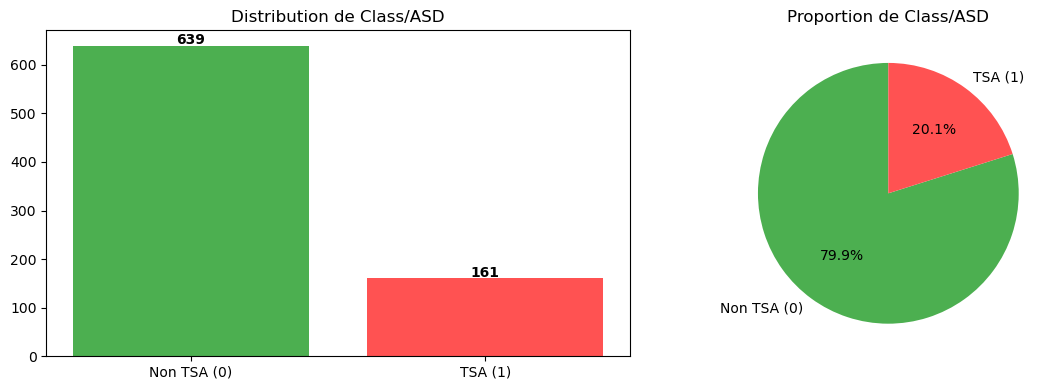

In [5]:
#  Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comptage = df['Class/ASD'].value_counts()

# Barres
axes[0].bar(['Non TSA (0)', 'TSA (1)'], comptage.values, color=['#4CAF50', '#FF5252'])
axes[0].set_title('Distribution de Class/ASD')
for i, v in enumerate(comptage.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Camembert
axes[1].pie(comptage.values, labels=['Non TSA (0)', 'TSA (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#FF5252'], startangle=90)
axes[1].set_title('Proportion de Class/ASD')

plt.tight_layout()
plt.show()

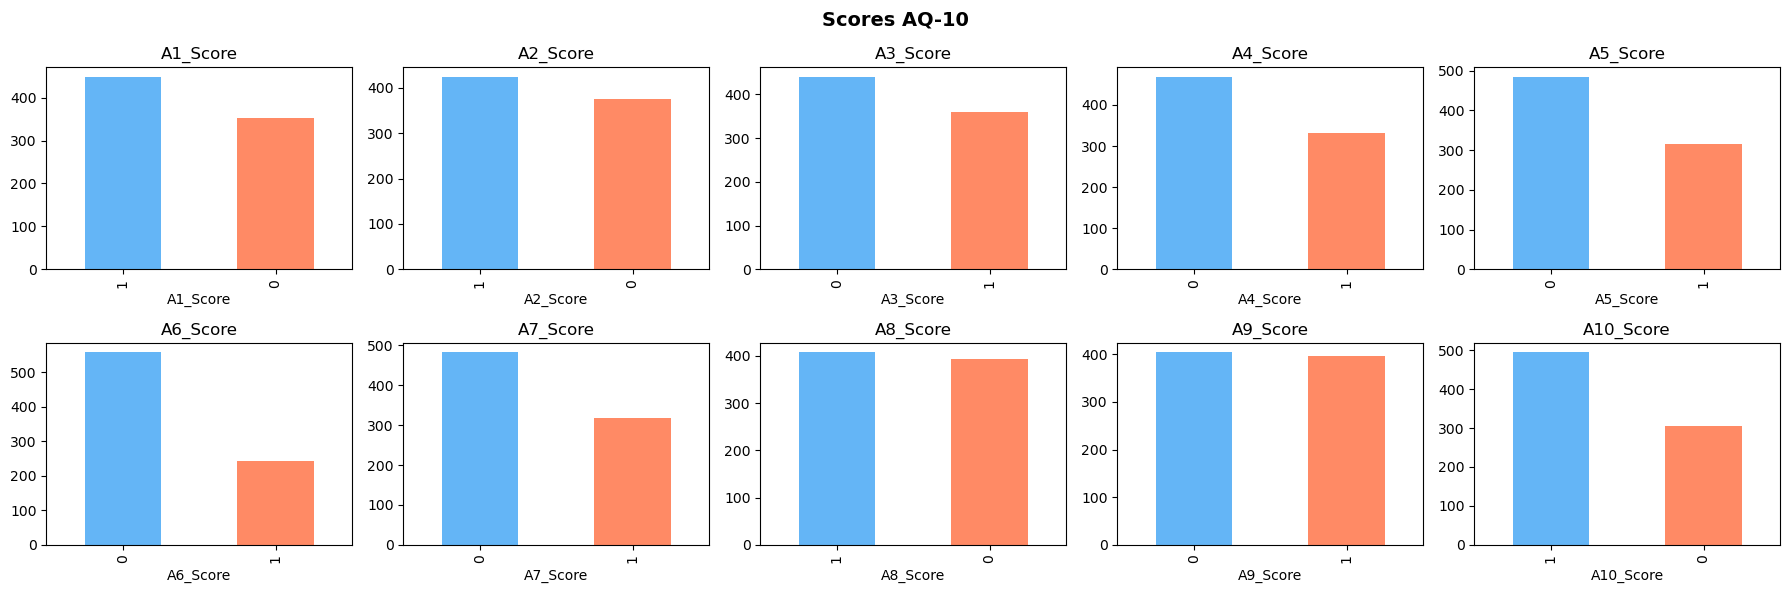

In [6]:
#  Distribution des scores AQ-10
fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for i in range(10):
    ax = axes[i // 5][i % 5]
    col = f'A{i+1}_Score'
    df[col].value_counts().plot(kind='bar', ax=ax, color=['#64B5F6', '#FF8A65'])
    ax.set_title(col)

plt.suptitle('Scores AQ-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

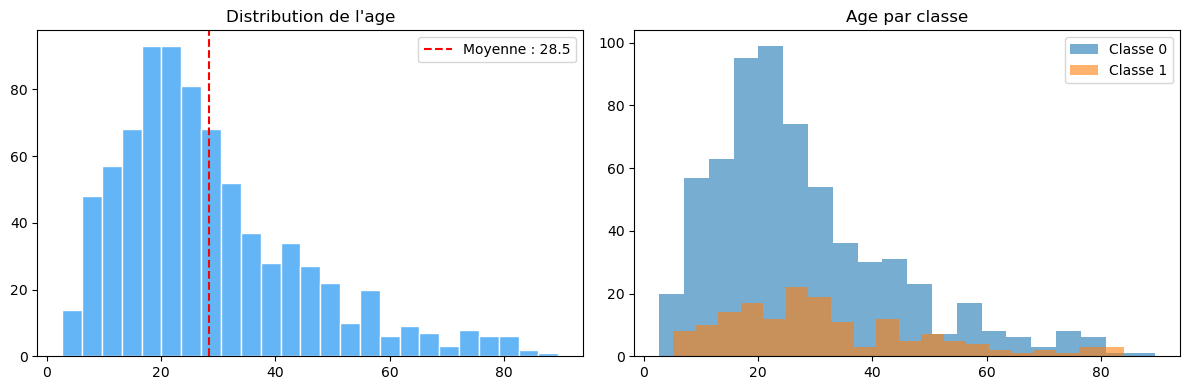

In [7]:
#  Distribution de l'age
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['age'], bins=25, color='#64B5F6', edgecolor='white')
axes[0].set_title("Distribution de l'age")
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['age'].mean():.1f}")
axes[0].legend()

for cls in [0, 1]:
    axes[1].hist(df[df['Class/ASD'] == cls]['age'], bins=20, alpha=0.6, label=f"Classe {cls}")
axes[1].set_title("Age par classe")
axes[1].legend()

plt.tight_layout()
plt.show()

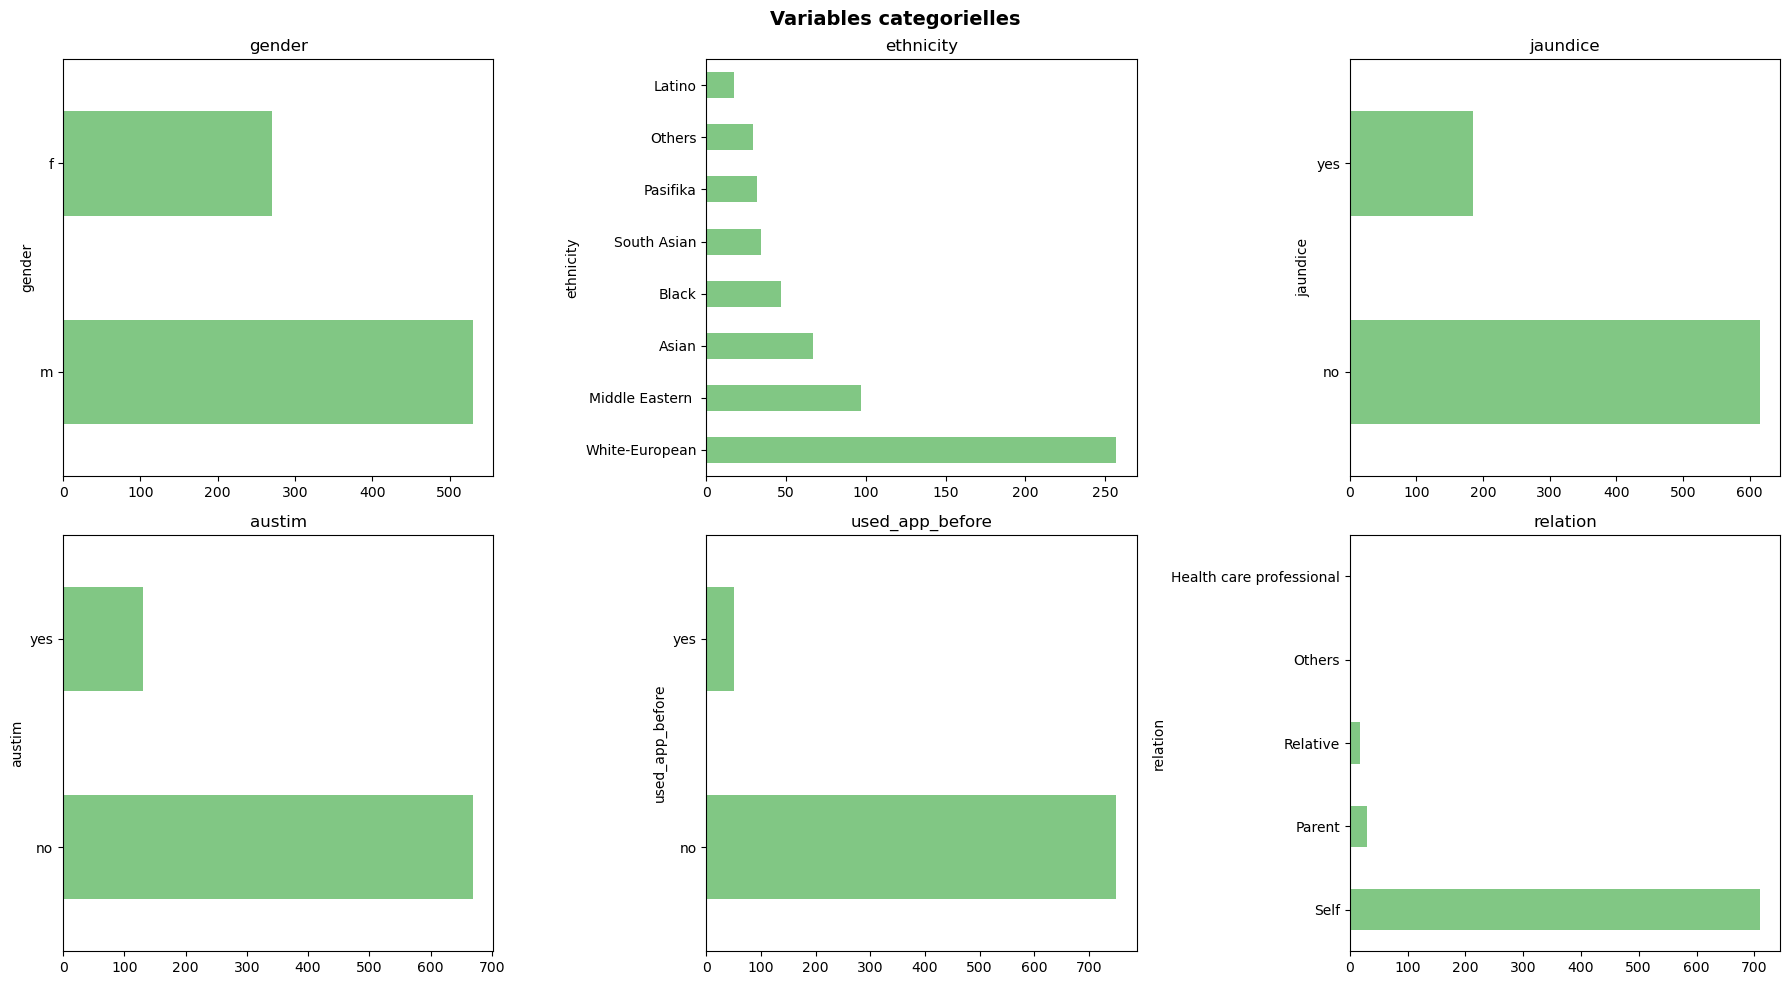

In [8]:
#  Variables categorielles
colonnes_cat = ['gender', 'ethnicity', 'jaundice', 'austim', 'used_app_before', 'relation']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(colonnes_cat):
    ax = axes[i // 3][i % 3]
    df[df[col] != '?'][col].value_counts().head(8).plot(kind='barh', ax=ax, color='#81C784')
    ax.set_title(col)

plt.suptitle('Variables categorielles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

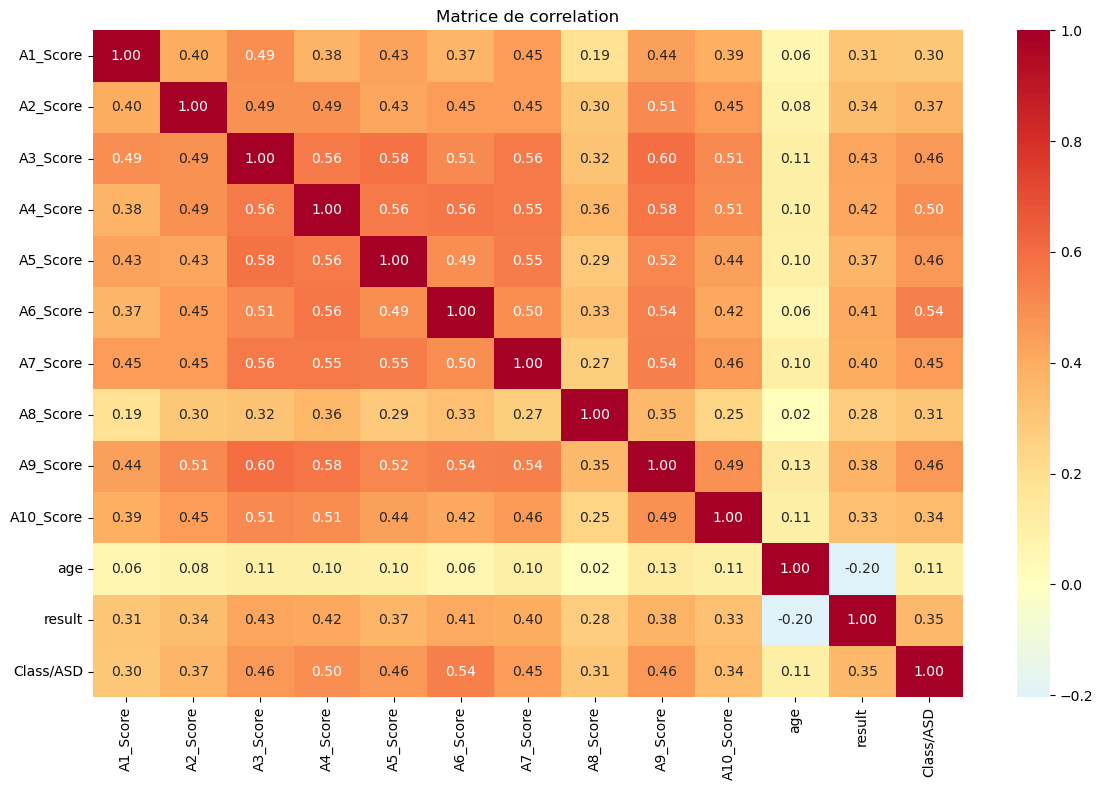

In [9]:
#  Matrice de correlation
colonnes_num = [f'A{i}_Score' for i in range(1, 11)] + ['age', 'result', 'Class/ASD']

plt.figure(figsize=(12, 8))
sns.heatmap(df[colonnes_num].corr(), annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
plt.title('Matrice de correlation')
plt.tight_layout()
plt.show()

In [10]:
#  Nettoyage des donnees
df_clean = df.copy()

# 1. Supprimer les colonnes inutiles
df_clean.drop(columns=['ID', 'age_desc'], inplace=True)

# 2. Remplacer '?' par le mode
df_clean.replace('?', np.nan, inplace=True)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# 3. Encodage des variables categorielles
encodeurs = {}
for col in df_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encodeurs[col] = le

# Sauvegarder les encodeurs
os.makedirs('../saved_models', exist_ok=True)
joblib.dump(encodeurs, '../saved_models/encoders.pkl')

print(" Nettoyage termine !")
print(f" Dimensions : {df_clean.shape}")
df_clean.head()

 Nettoyage termine !
 Dimensions : (800, 20)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.172746,0,9,0,0,7,0,6.351166,4,0
1,0,0,0,0,0,0,0,0,0,0,47.750517,1,9,0,0,25,0,2.255185,4,0
2,1,1,1,1,1,1,1,1,1,1,7.380373,1,9,0,1,54,0,14.851484,4,1
3,0,0,0,0,0,0,0,0,0,0,23.561927,0,9,0,0,54,0,2.276617,4,0
4,0,0,0,0,0,0,0,0,0,0,43.205790,1,9,0,0,46,0,-4.777286,4,0


In [13]:
#  Separation et preparation
X = df_clean.drop(columns=['Class/ASD', 'result'])
y = df_clean['Class/ASD']

# Normalisation
normaliseur = StandardScaler()
X_normalise = pd.DataFrame(normaliseur.fit_transform(X), columns=X.columns)
joblib.dump(normaliseur, '../saved_models/scaler.pkl')

# Division 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_normalise, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE sur les donnees d'entrainement
smote = SMOTE(random_state=42)
X_train_eq, y_train_eq = smote.fit_resample(X_train, y_train)

print(f" Avant SMOTE  → Classe 0 : {(y_train==0).sum()} | Classe 1 : {(y_train==1).sum()}")
print(f" Apres SMOTE  → Classe 0 : {(y_train_eq==0).sum()} | Classe 1 : {(y_train_eq==1).sum()}")
print(f" Test         → Classe 0 : {(y_test==0).sum()} | Classe 1 : {(y_test==1).sum()}")

 Avant SMOTE  → Classe 0 : 511 | Classe 1 : 129
 Apres SMOTE  → Classe 0 : 511 | Classe 1 : 511
 Test         → Classe 0 : 128 | Classe 1 : 32


In [12]:
#  Sauvegarde des donnees traitees
donnees = {
    'X_train': X_train_eq,
    'X_test': X_test,
    'y_train': y_train_eq,
    'y_test': y_test,
    'noms_colonnes': list(X.columns)
}

with open('../data/donnees_traitees.pkl', 'wb') as f:
    pickle.dump(donnees, f)

print(" Donnees sauvegardees dans '../data/donnees_traitees.pkl'")
print(f" Caracteristiques : {list(X.columns)}")
print(f" Entrainement : {len(X_train_eq)} | Test : {len(X_test)}")

 Donnees sauvegardees dans '../data/donnees_traitees.pkl'
 Caracteristiques : ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']
 Entrainement : 1022 | Test : 160
